In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install zipfile
import zipfile

# filename = "/content/drive/MyDrive/Colab_Notebooks/DRIVE_Augmented.zip"

# filename = "/content/drive/MyDrive/Colab_Notebooks/IOSTAR_Original.zip"
filename = "/content/drive/MyDrive/Colab_Notebooks/RAVIR_Original.zip"
# Use the RarFile class from the rarfile library
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall()
    print('Done')

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile
Done


In [3]:

import os
!pip install Keras-Preprocessing
import tensorflow as tf
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

from tqdm import tqdm_notebook, tnrange
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
import imageio

from keras.models import Model, load_model
from keras.layers import Input, BatchNormalization, Activation, Dense, Dropout, Resizing
from keras.layers import Lambda, RepeatVector, Reshape
from keras.layers import Conv2D, Conv2DTranspose
from keras.layers import MaxPooling2D, GlobalMaxPool2D, AveragePooling2D
from keras.regularizers import l2
#from keras.layers.merge import concatenate, add
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras_preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import *
from keras.losses import *
from keras import backend as keras

from keras.utils import plot_model
import cv2
import skimage.io as io

import glob
from PIL import Image
import skimage
from keras.initializers import Constant

from skimage.morphology import disk
from sklearn.metrics import confusion_matrix
from skimage.measure import label, regionprops
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import jaccard_score

from keras import backend as K

from keras import layers, models
import zipfile
import random
import sys

import skimage.io                           #Used for imshow function
import skimage.transform                    #Used for resize function
from skimage.morphology import label        #Used for Run-Length-Encoding RLE to create final submission
import matplotlib.pyplot as plt
from keras.layers import Concatenate, add

import warnings
warnings.filterwarnings("ignore")
random.seed(42)
from keras.losses import binary_crossentropy
from sklearn.metrics import precision_recall_curve

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00


In [4]:
dataset_dir = '/content/IOSTAR_Original'
os.listdir(dataset_dir)

['test', 'train']

In [5]:
from keras import backend as K

from scipy.ndimage import distance_transform_edt as distance
from keras.losses import binary_crossentropy
def dice_coef(y_true, y_pred,smooth = 10):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

def Jaccard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection ) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection)

def Jaccard_coef_loss(y_true, y_pred):
    return (1-Jaccard_coef(y_true, y_pred))

# def bcc_Jaccard_coef_loss(y_true, y_pred):
#     return (binary_crossentropy(y_true, y_pred)+(1-Jaccard_coef(y_true, y_pred)))

#Metrices
# from keras import backend as K
import tensorflow as tf
import keras

import tensorflow.keras.backend as K  # Import the correct backend

# ... (rest of your code)

def iou(y_true, y_pred, threshold=0.5):
    y_pred = threshold_binarize(y_pred, threshold)
    y_true_f = K.flatten(y_true)  # Now use K.flatten from tensorflow.keras.backend
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)

import keras.backend as K  # Make sure to import Keras backend

def dice_coef(y_true, y_pred, threshold=0.5):
    y_pred = threshold_binarize(y_pred, threshold)
    y_true_f = K.flatten(y_true)  # Now use K.flatten
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    # ... rest of your dice_coef function ...
    return (2. * intersection) / (K.sum(y_true_f) + K.sum(y_pred_f))

def sensitivity(y_train, results):
    true_positives = K.sum(K.round(K.clip(y_train * results, 0, 1)))
    actual_positives = K.sum(K.round(K.clip(y_train, 0, 1)))
    sensitivity = true_positives / (actual_positives + K.epsilon())
    return sensitivity

def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def threshold_binarize(x, threshold=0.5):
    ge = tf.greater_equal(x, tf.constant(threshold))
    y = tf.where(ge, x=tf.ones_like(x), y=tf.zeros_like(x))
    return y

def DiceLoss(y_true, y_pred, smooth=1e-6):
    y_true, y_pred = tf.cast(y_true, dtype=tf.float32), tf.cast(y_pred, tf.float32)
    nominator = 2 * tf.reduce_sum(tf.multiply(y_pred, y_true)) + smooth
    denominator = tf.reduce_sum(y_pred ** 2) + tf.reduce_sum(y_true ** 2) + smooth
    result = 1 - tf.divide(nominator, denominator)
    return result



# def bcc_Jaccard_coef_loss(y_true, y_pred):
#     return (DiceLoss(y_true, y_pred, smooth=1e-6)+(1-iou(y_true, y_pred, threshold=0.5)))


def bcc_Jaccard_coef_loss(y_true, y_pred):
    iou_value = iou(y_true, y_pred, threshold=0.5)  # Calculate IoU
    print("IoU value:", iou_value)  # Print the IoU value
    return (DiceLoss(y_true, y_pred, smooth=1e-6)+(1-iou_value))


In [6]:
# from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate
# from keras import backend as K

# # def cbam_block(cbam_feature, ratio=8):
# #     """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
# #     As described in https://arxiv.org/abs/1807.06521.
# #     """

# #     cbam_feature = channel_attention(cbam_feature, ratio)
# #     cbam_feature = spatial_attention(cbam_feature)
# #     return cbam_feature

# # def channel_attention(input_feature, ratio=8):
# #     channel_axis = 1 if K.image_data_format() == "channels_first" else -1
# #     channel = input_feature.shape[channel_axis]

# #     shared_layer_one = Dense(channel//ratio,
# #                              activation='relu',
# #                              kernel_initializer='he_normal',
# #                              use_bias=True,
# #                              bias_initializer='zeros')
# #     shared_layer_two = Dense(channel,
# #                              kernel_initializer='he_normal',
# #                              use_bias=True,
# #                              bias_initializer='zeros')

# #     avg_pool = GlobalAveragePooling2D()(input_feature)
# #     avg_pool = Reshape((1,1,channel))(avg_pool)
# #     assert avg_pool.shape[1:] == (1,1,channel)
# #     avg_pool = shared_layer_one(avg_pool)
# #     assert avg_pool.shape[1:] == (1,1,channel//ratio)
# #     avg_pool = shared_layer_two(avg_pool)
# #     assert avg_pool.shape[1:] == (1,1,channel)

# #     max_pool = GlobalMaxPooling2D()(input_feature)
# #     max_pool = Reshape((1,1,channel))(max_pool)
# #     assert max_pool.shape[1:] == (1,1,channel)
# #     max_pool = shared_layer_one(max_pool)
# #     assert max_pool.shape[1:] == (1,1,channel//ratio)
# #     max_pool = shared_layer_two(max_pool)
# #     assert max_pool.shape[1:] == (1,1,channel)

# #     cbam_feature = Add()([avg_pool,max_pool])
# #     cbam_feature = Activation('sigmoid')(cbam_feature)

# #     if K.image_data_format() == "channels_first":
# #         cbam_feature = Permute((3, 1, 2))(cbam_feature)

# #     return multiply([input_feature, cbam_feature])

# # def spatial_attention(input_feature):
# #     kernel_size = 7

# #     if K.image_data_format() == "channels_first":
# #         channel = input_feature.shape[1]
# #         cbam_feature = Permute((2,3,1))(input_feature)
# #     else:
# #         channel = input_feature.shape[-1]
# #         cbam_feature = input_feature


# #     avg_pool = Lambda(lambda x: K.mean(x, axis=3, keepdims=True))(cbam_feature)
# #     assert avg_pool.shape[-1] == 1
# #     max_pool = Lambda(lambda x: K.max(x, axis=3, keepdims=True))(cbam_feature)
# #     assert max_pool.shape[-1] == 1
# #     concat = Concatenate(axis=3)([avg_pool, max_pool])
# #     assert concat.shape[-1] == 2
# #     cbam_feature = Conv2D(filters = 1,
# #                     kernel_size=kernel_size,
# #                     strides=1,
# #                     padding='same',
# #                     activation='sigmoid',
# #                     kernel_initializer='he_normal',
# #                     use_bias=False)(concat)
# #     assert cbam_feature.shape[-1] == 1

# #     if K.image_data_format() == "channels_first":
# #         cbam_feature = Permute((3, 1, 2))(cbam_feature)

# #     return multiply([input_feature, cbam_feature])

# def create_transfuse_net(input_shape):
#     # Define the input layer
#     inputs = layers.Input(shape=input_shape)

#     # Encoder - Convolutional Blocks
#     conv_block1 = layers.Conv2D(8, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
#     conv_block1 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block1)
#     conv_block1 = layers.BatchNormalization()(conv_block1)

#     conv_block2 = layers.Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu')(conv_block1)
#     conv_block2 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block2)
#     conv_block2 = layers.BatchNormalization()(conv_block2)

#     conv_block3 = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu')(conv_block2)
#     conv_block3 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block3)
#     conv_block3 = layers.BatchNormalization()(conv_block3)

#     # Encoder - Transformer Block
#     transformer_block = layers.Reshape((-1, conv_block3.shape[3]))(conv_block3)
#     transformer_block = layers.MultiHeadAttention(num_heads=4, key_dim=32)(transformer_block, transformer_block)
#     transformer_block = layers.GlobalAveragePooling1D()(transformer_block)
#     transformer_block = layers.Reshape((1, 1, transformer_block.shape[1]))(transformer_block)

#     # Tile the transformer block output to match the spatial dimensions of the convolutional block
#     transformer_block = layers.Lambda(lambda x: tf.tile(x, [1, conv_block3.shape[1], conv_block3.shape[2], 1]))(transformer_block)

#     # Concatenate the Encoder Convolutional and Transformer blocks

#     # att1 = cbam_block(transformer_block)
#     fused_features = layers.Concatenate()([conv_block3, transformer_block])

#     # Decoder - Upsampling Blocks
#     decoder_block1 = layers.Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(fused_features)
#     # att2=cbam_block(decoder_block1)
#     decoder_block1 = layers.Concatenate()([decoder_block1, conv_block2])
#     decoder_block1 = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block1)

#     decoder_block2 = layers.Conv2DTranspose(16, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_block1)

#     # att3=cbam_block(decoder_block2)
#     decoder_block2 = layers.Concatenate()([decoder_block2, conv_block1])
#     decoder_block2 = layers.Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block2)


#     decoder_block3 = layers.Conv2DTranspose(8, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_block2)
#     decoder_block3 = layers.Conv2D(8, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block3)
#     # Decoder - Output Block
#     output_BV = layers.Conv2D(1, kernel_size=(1, 1), activation='sigmoid',name = 'final_output1')(decoder_block3)
#     # output_OD = layers.Conv2D(1, kernel_size=(1, 1), activation='sigmoid', name = 'final_output2')(decoder_block3)

#     # Create the model
#     model = models.Model(inputs=inputs, outputs=[output_BV])

#     return model

# # Define the input shape for binary semantic segmentation
# input_shape = (512,512,3)  # Example input shape for RGB images

# # Create the TransFuse Encoder-Decoder model with 3 MaxPooling layers for binary semantic segmentation
# model = create_transfuse_net(input_shape)


In [7]:
from tensorflow.keras import layers
from tensorflow.keras.layers import ZeroPadding2D, Cropping2D
def focal_modulation_block(inputs, gamma=2.0, alpha=0.25):
    # Get the number of channels in the input tensor
    num_channels = inputs.shape[-1]

    # Channel-wise mean calculation
    mean = layers.GlobalAveragePooling2D()(inputs)

    # Channel-wise max calculation
    max_val = layers.GlobalMaxPooling2D()(inputs)

    # Calculate the modulation factor for each channel
    modulation = (max_val - mean) * alpha

    # Apply the focal modulation to the input tensor
    modulation = layers.Reshape((1, 1, num_channels))(modulation)
    modulation = layers.Conv2D(filters=num_channels, kernel_size=1, activation='sigmoid')(modulation)

    # Scale the input tensor by the modulation factor
    scaled_inputs = layers.Multiply()([inputs, modulation])

    # Apply gamma power to the scaled inputs
    outputs = layers.Lambda(lambda x: x ** gamma)(scaled_inputs)

    return outputs

def focal_modulation_context_aggregation_block(inputs,filters):
    #After cancate the output will duble the filter and make it same for addition
    filters = int(filters)
    # Apply 2D convolution to capture local context
    conv1 = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(inputs)

    # Apply 2D convolution to capture global context
    conv2 = layers.Conv2D(filters, kernel_size=1, activation='relu')(inputs)
    global_context = layers.GlobalAveragePooling2D()(conv2)
    global_context = layers.Reshape((1, 1, filters))(global_context)
    global_context = layers.Conv2D(filters, kernel_size=1, activation='sigmoid')(global_context)
    global_context = layers.Multiply()([conv1, global_context])

    # Apply focal modulation block
    focal_modulation = focal_modulation_block(global_context)

    # Concatenate the local context and focal modulation output
    concatenated = layers.Concatenate()([conv1, focal_modulation])
    # add_features = add([conv1, focal_modulation])

    return concatenated

# from skimage.measure import block_reduce
import numpy as geek
def sem_attention_block(inputs):
    shape=inputs.shape
    F2=Conv2D(shape[3],1, padding='same') (inputs)
    F2=BatchNormalization() (F2)
    F2=Activation('relu') (F2)
    x1=MaxPooling2D(pool_size=(shape[1],shape[2]),padding='same')(F2)
    x2=AveragePooling2D(pool_size=(shape[1],shape[2]),padding='same')(F2)
    con1 = Concatenate()([x1,x2])
    F3=Conv2D(shape[3],1, padding='same') (con1)
    F3=BatchNormalization() (F3)
    F33=Activation('relu') (F3)
    xa=GlobalAveragePooling2D(keepdims=True)(inputs)
    xa=Conv2D(shape[3],1, padding='same') (xa)
    xaa=BatchNormalization() (xa)
    xaa=Activation('sigmoid') (xaa)
    xm=Multiply()([F33,xaa])
    xam=Add()([inputs,xm])
    return xam

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import ZeroPadding2D, Cropping2D

def create_transfuse_net(input_shape, num_classes):
    # Define the input layer
    inputs = layers.Input(shape=input_shape)
    F = 3

    # Encoder - Convolutional Blocks
    conv_block1 = layers.Conv2D(F*8, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
    conv_block1_1x1 = layers.Conv2D(F*8, kernel_size=(1, 1), padding='same', activation='relu')(conv_block1)
    conv_block1 = layers.Concatenate()([conv_block1, conv_block1_1x1])
    conv_block1 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block1)
    conv_block1 = layers.BatchNormalization()(conv_block1)

    conv_block2 = layers.Conv2D(F*16, kernel_size=(3, 3), padding='same', activation='relu')(conv_block1)
    conv_block2_1x1 = layers.Conv2D(F*16, kernel_size=(1, 1), padding='same', activation='relu')(conv_block1)
    conv_block2 = layers.Concatenate()([conv_block2, conv_block2_1x1])
    conv_block2 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block2)
    conv_block2 = layers.BatchNormalization()(conv_block2)

    conv_block3 = layers.Conv2D(F*32, kernel_size=(3, 3), padding='same', activation='relu')(conv_block2)
    conv_block3_1x1 = layers.Conv2D(F*32, kernel_size=(1, 1), padding='same', activation='relu')(conv_block2)
    conv_block3 = layers.Concatenate()([conv_block3, conv_block3_1x1])
    conv_block3 = layers.MaxPooling2D(pool_size=(2, 2))(conv_block3)
    conv_block3 = layers.BatchNormalization()(conv_block3)
    conv_block3 = layers.Dropout(0.5)(conv_block3)

    # Focal Modulation Block (Placeholder)
    focal_modulation = focal_modulation_context_aggregation_block(conv_block3, 16)

    # Attention Block
    att1 = sem_attention_block(focal_modulation)
    fused_features = layers.Concatenate()([conv_block3, att1])

    # Decoder - Upsampling Blocks
    decoder_block1 = layers.Conv2DTranspose(F*32, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(fused_features)
    att2 = sem_attention_block(decoder_block1)
    att22 = sem_attention_block(conv_block2)

    # Adjust shapes before concatenation
    if att2.shape[1] != att22.shape[1] or att2.shape[2] != att22.shape[2]:
        # Match the spatial dimensions
        att2 = ZeroPadding2D(((0, 0), (1, 0)))(att2)  # Pad att2 to match att22

    # Concatenate
    decoder_block1 = layers.Concatenate()([att2, att22])
    decoder_block1 = layers.Conv2D(F*32, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block1)

    decoder_block2 = layers.Conv2DTranspose(F*16, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_block1)
    att3 = sem_attention_block(decoder_block2)
    att33 = sem_attention_block(conv_block1)

    if att3.shape[1] != att33.shape[1] or att3.shape[2] != att33.shape[2]:
        att3 = ZeroPadding2D(((0, 0), (1, 0)))(att3)  # Match dimensions with att33

    decoder_block2 = layers.Concatenate()([att3, att33])
    decoder_block2 = layers.Conv2D(F*16, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block2)

    decoder_block3 = layers.Conv2DTranspose(F*8, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_block2)
    att4 = sem_attention_block(decoder_block3)
    att44 = sem_attention_block(conv_block1_1x1)

    if att4.shape[1] != att44.shape[1] or att4.shape[2] != att44.shape[2]:
        att4 = ZeroPadding2D(((0, 0), (1, 0)))(att4)  # Match dimensions with att44

    decoder_block3 = layers.Concatenate()([att4, att44])
    decoder_block3 = layers.Conv2D(F*8, kernel_size=(3, 3), padding='same', activation='relu')(decoder_block3)

    # Decoder - Output Block
    output_BV = layers.Conv2D(1, kernel_size=(1, 1), activation='sigmoid', name='final_output1')(decoder_block3)

    # Create the model
    model = models.Model(inputs=[inputs], outputs=[output_BV])

    return model

# Define the input shape for binary semantic segmentation
input_shape = (512, 512, 3)

# Create the TransFuse Encoder-Decoder model with 3 MaxPooling layers for binary semantic segmentation
model = create_transfuse_net(input_shape, 1)

# Print the model summary to ensure everything is correct
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 512, 512, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 512, 512, 24)   │            672 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 512, 512, 24)   │            600 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 512, 512, 48)   │              0 │ conv2d[0][0],          │
│                           │                        │                │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 256, 256, 48)   │              0 │ concatenate[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 48)   │            192 │ max_pooling2d[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 256, 256, 48)   │         20,784 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 256, 256, 48)   │          2,352 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256, 256, 96)   │              0 │ conv2d_2[0][0],        │
│ (Concatenate)             │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 128, 128, 96)   │              0 │ concatenate_1[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 96)   │            384 │ max_pooling2d_1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 96)   │         83,040 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 128, 128, 96)   │          9,312 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 128, 128, 192)  │              0 │ conv2d_4[0][0],        │
│ (Concatenate)             │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 64, 64, 192)    │              0 │ concatenate_2[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2

 Total params: 719,249 (2.74 MB)

 Trainable params: 716,369 (2.73 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [9]:
# model.compile(optimizer=tf.keras.optimizers.Adam(),
#               loss={'final_output1': DiceLoss},
#               metrics={'final_output1': [dice_coef, iou, sensitivity, specificity]})

# model.summary()

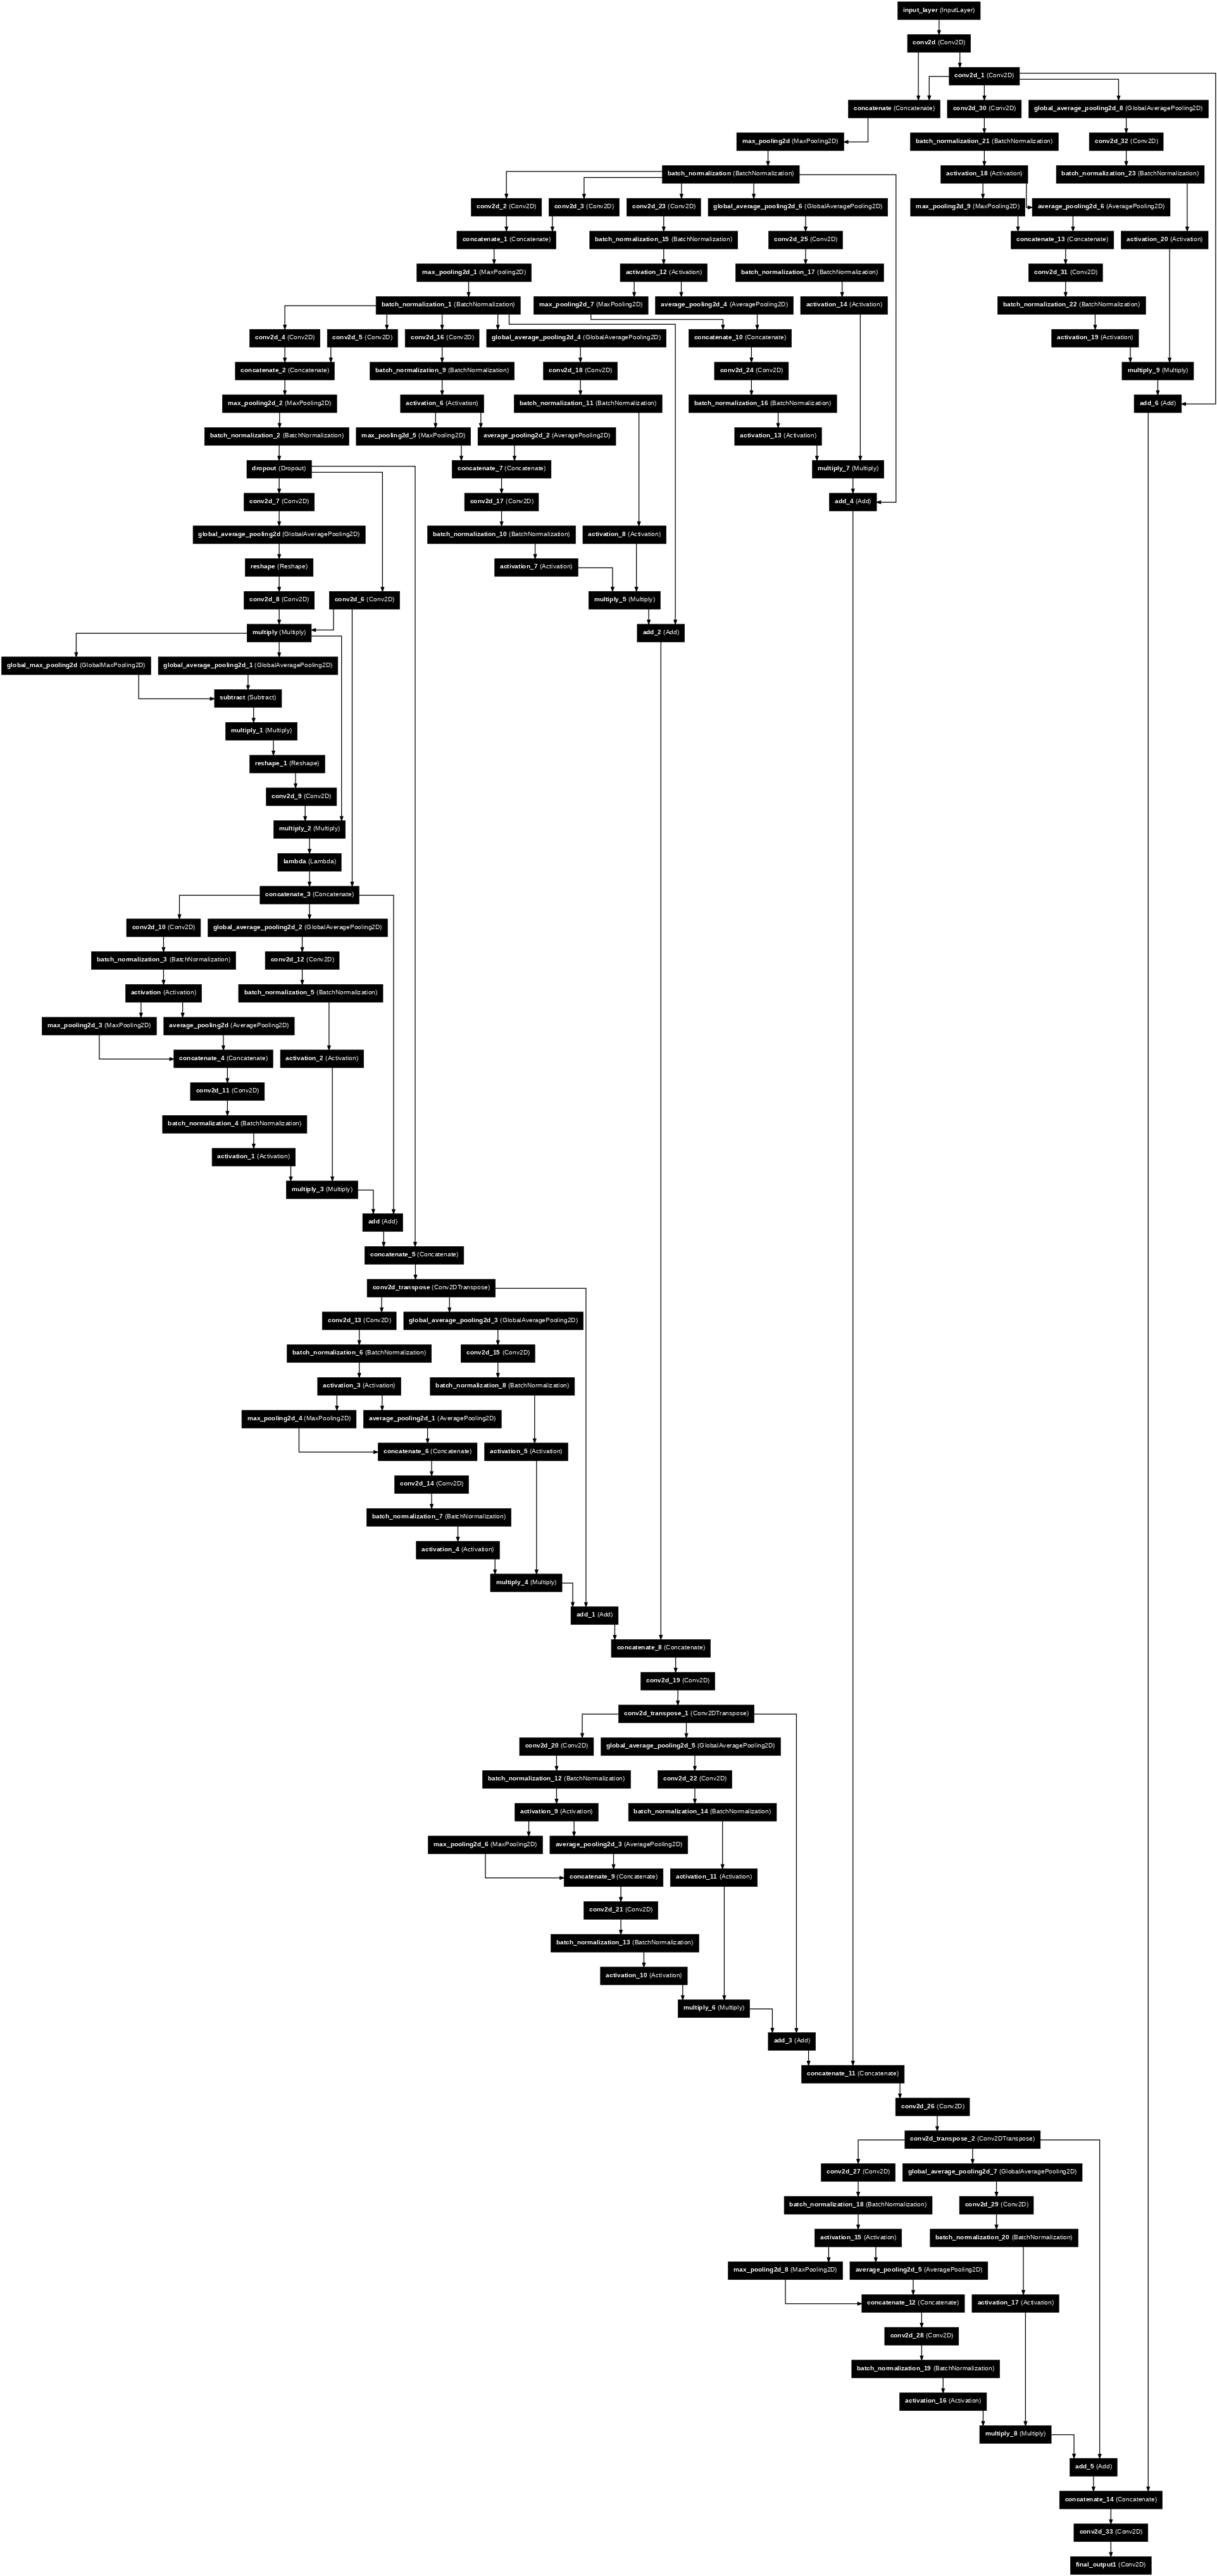

In [10]:
tf.keras.utils.plot_model(
    model,
    show_shapes=False,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False,
    dpi=46,
    layer_range=None
)

In [11]:
# train_data ='/content/DRIVE_BioNet-Augmented/train' #data path
# valid_data = '/content/DRIVE_BioNet-Augmented/test'
train_data ='/content/IOSTAR_Original/train' #data path
valid_data = '/content/IOSTAR_Original/test'

In [12]:

import os
import numpy as np
im_height=512
im_width=512
# Get and resize train images and masks
def get_data(path):
    images_paths = os.path.join(path,'images')
    masks_path_BV = os.path.join(path,'GT_BV')

    # images_ids = os.listdir(images_paths)
    # masks_ids = os.listdir(masks_paths)
    images_ids = sorted(os.listdir(images_paths))
    mask1_ids = sorted(os.listdir(masks_path_BV))

    X = np.zeros((len(images_ids), im_height, im_width, 3), dtype=np.float32)
    y1 = np.zeros((len(mask1_ids), im_height, im_width, 1), dtype=np.float32)
    print('Getting and resizing images ... ')
    for n in range (len(images_ids)):
        # Load images
        img = img_to_array(load_img(os.path.join(images_paths,images_ids[n]), grayscale=False))
        x_img = resize(img, (im_height, im_width, 3), mode='constant', preserve_range=True)

        # Load masks
        mask_BV = img_to_array(load_img(os.path.join(masks_path_BV,mask1_ids[n]), grayscale=True))
        mask_BV = resize( mask_BV, (im_height, im_width, 1), mode='constant', preserve_range=True)

        # Save images
        X[n] = x_img/ 255
        y1[n] = mask_BV/ 255

    print('Done!')
    return X, y1


In [13]:
X, y1 = get_data(train_data)

print("X_train shape:", X.shape)
print("y1_train shape:", y1.shape)

Getting and resizing images ... 
Done!
X_train shape: (25, 512, 512, 3)
y1_train shape: (25, 512, 512, 1)


In [14]:
# prompt: ADD TRAIN TEST SPLIT AND PRINT SHAPES

# Get and resize train images and masks

X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.20, random_state=42)


# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y1_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y1_test shape:", y_test.shape)


X_train shape: (20, 512, 512, 3)
y1_train shape: (20, 512, 512, 1)
X_test shape: (5, 512, 512, 3)
y1_test shape: (5, 512, 512, 1)


In [15]:
# prompt: convert masks into logical values and print shapes

y_train = np.array(y_train > 0.5, dtype=np.uint8)
y_test = np.array(y_test > 0.5, dtype=np.uint8)
# y2_train_od = np.array(y2_train_od > 0.5, dtype=np.uint8)
# y2_test_od = np.array(y2_test_od > 0.5, dtype=np.uint8)




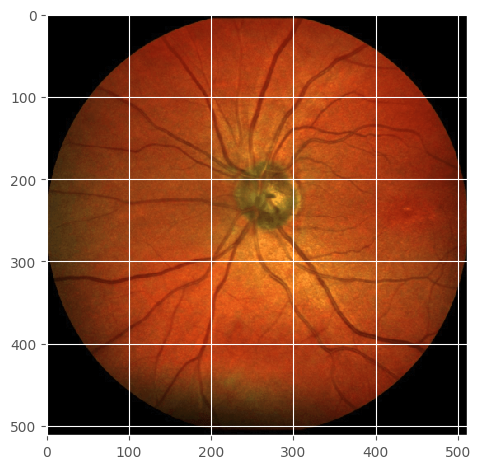

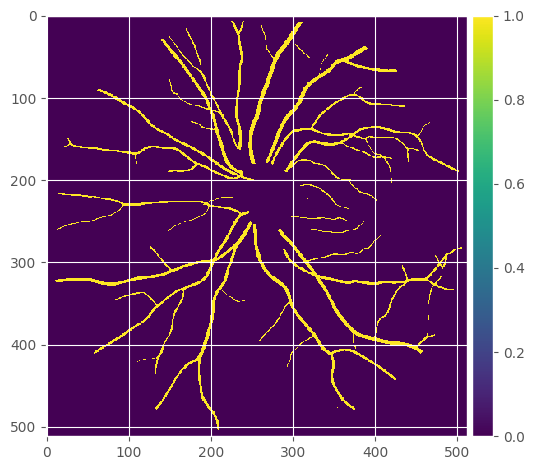

[0 1]


In [16]:
# prompt: display masks and print unique values

ix = random.randint(0, len(X_train))
imshow(X_train[ix])
plt.show()
imshow(np.squeeze(y_train[ix]))
plt.show()


print(np.unique(y_train[ix]))
# print(np.unique(y_test[ix]))


In [17]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
nb_epoch = 300
batch_size=8
earlystopper = EarlyStopping(patience=10, verbose=1)
# Append '.weights.h5' to the filename
checkpoint = ModelCheckpoint('/content/drive/MyDrive/New_LAV-Net/IOSTAR_LAV-Net_Weights.weights.h5',
                             verbose=1, save_best_only=True,save_weights_only=True)
callbacks = [checkpoint, earlystopper]

In [18]:
# prompt: load model weights

model.load_weights('/content/drive/MyDrive/New_LAV-Net/LAV-Net_Weights_Dice_1.weights.h5')


In [19]:
# Assuming 'model' is your Keras model object
model.compile(optimizer='adam', loss=DiceLoss, metrics=['accuracy'])  # Or any suitable optimizer, loss, and metrics

results = model.fit(
    X_train,
    [y_train],
    batch_size=batch_size,
    epochs=nb_epoch,
    callbacks=callbacks,
    validation_data=(X_test, [y_test])
)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9561 - loss: 0.2321  
Epoch 1: val_loss improved from inf to 0.18557, saving model to /content/drive/MyDrive/New_LAV-Net/IOSTAR_LAV-Net_Weights.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 136s 32s/step - accuracy: 0.9569 - loss: 0.2303 - val_accuracy: 0.9654 - val_loss: 0.1856
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9690 - loss: 0.1804
Epoch 2: val_loss did not improve from 0.18557
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.9686 - loss: 0.1805 - val_accuracy: 0.9608 - val_loss: 0.2027
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9671 - loss: 0.1774
Epoch 3: val_loss did not improve from 0.18557
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step - accuracy: 0.9671 - loss: 0.1771 - val_accuracy: 0.9634 - val_loss: 0.1920
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9698 - loss: 0.1717
Epoch 4: val_loss improved from 0.18557 to 0.18316, saving model to /content/drive/MyDri

In [20]:
def evaluate_metrics(y_test, y_pred):
  n = y_pred.shape[0]
  all_F1_score = np.zeros(n)
  all_dice = np.zeros(n)
  all_jaccard = np.zeros(n)
  all_sensitivity = np.zeros(n)
  all_specificity = np.zeros(n)
  for i in range(n):
      gt, pred = y_test[i], y_pred[i]
      gt_flt = np.ndarray.flatten(gt)
      pred_flt = np.ndarray.flatten(pred)

      precisions, recalls, thresholds = precision_recall_curve(gt_flt, pred_flt)
      f1 = 2*(precisions * recalls) / (precisions + recalls)
      max_value = np.argmax(f1)
      thres = thresholds[max_value]
      pred_mask = (pred_flt >= thres)
      pred_label = pred_mask*1

      tn, fp, fn, tp = confusion_matrix(gt_flt, pred_label).ravel()

      F1_score = tp/(tp+((0.5)*(fp+fn)))
      iou = tp / (tp + fp + fn)
      dice = 2*tp / (2*tp + fp + fn)
      specificity = tn / (tn + fp)
      recall = tp / (tp + fn)

      all_F1_score[i] = F1_score
      all_dice[i] = dice
      all_jaccard[i] = iou
      all_sensitivity[i] = recall
      all_specificity[i] = specificity

  print(' F1_score: {:4f}, Dice: {:4f}, Jaccard: {:4f}, Sensitivity: {:4f}, Specificity: {:4f}'.format(
        np.nanmean(all_F1_score), np.nanmean(all_dice), np.nanmean(all_jaccard), np.nanmean(all_sensitivity), np.nanmean(all_specificity)
  ))
  return all_F1_score, all_dice, all_jaccard, all_sensitivity, all_specificity


In [21]:
# valid_data = '/content/ISIC2018_256x256/test' #data path
X_test, y_test = get_data(valid_data)

Getting and resizing images ... 
Done!


In [22]:
from sklearn.metrics import precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

def evaluate_metrics(y_test, y_pred, return_mode='all'):
    n = y_pred.shape[0]
    all_accuracy = np.zeros(n)
    all_dice = np.zeros(n)
    all_jaccard = np.zeros(n)
    all_sensitivity = np.zeros(n)
    all_specificity = np.zeros(n)
    for i in range(n):
        gt, pred = y_test[i], y_pred[i]
        gt_flt = np.ndarray.flatten(gt)
        pred_flt = np.ndarray.flatten(pred)

        precisions, recalls, thresholds = precision_recall_curve(gt_flt, pred_flt)
        f1 = 2*(precisions * recalls) / (precisions + recalls)
        max_value = np.argmax(f1)
        precision, recall, thres = precisions[max_value], recalls[max_value], thresholds[max_value]

        maxval = 255
        pred_mask = (pred_flt > thres)
        pred_label = pred_mask*1

        tn, fp, fn, tp = confusion_matrix(gt_flt, pred_label).ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        iou = tp / (tp + fp + fn)
        dice = 2*tp / (2*tp + fp + fn)
        specificity = tn / (tn + fp)

        all_accuracy[i] = accuracy
        all_dice[i] = dice
        all_jaccard[i] = iou
        all_sensitivity[i] = recall
        all_specificity[i] = specificity

    print('Accuracy: {:4f}, Dice: {:4f}, Jaccard: {:4f}, Sensitivity: {:4f}, Specificity: {:4f}'.format(
        np.nanmean(all_accuracy), np.nanmean(all_dice), np.nanmean(all_jaccard), np.nanmean(all_sensitivity), np.nanmean(all_specificity)
    ))
    if return_mode == 'all':
        return all_accuracy, all_dice, all_jaccard, all_sensitivity, all_specificity
    if return_mode == 'value':
        return np.nanmean(all_accuracy), np.nanmean(all_dice), np.nanmean(all_jaccard), np.nanmean(all_sensitivity), np.nanmean(all_specificity)
    else:
        return 'No val returned'

In [23]:
# Convert ground truth labels to binary
y_test_BV = (y_test[0] > 0.5).astype(np.uint8)
# y_test_OD = (y_test[1] > 0.5).astype(np.uint8)

y_pred = model.predict(X_test, batch_size=1, verbose=1)

# y_pred = model.predict(X_test)
# evl = evaluate_metrics(y_test_BV, y_pred, return_mode='all')

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step


In [27]:
save_dir = '/content/drive/MyDrive/New_LAV-Net/IOSTAR'
os.makedirs(save_dir, exist_ok=True)
for i in range(len(y_pred)):
  plt.imsave("/content/drive/MyDrive/New_LAV-Net/IOSTAR/"+str(i+1)+"_Pred.png",y_pred[i,:,:,0],cmap='gray') # binary segmenation
  plt.imsave("/content/drive/MyDrive/New_LAV-Net/IOSTAR/"+str(i+1)+"_GT.png",y_test[i,:,:,0],cmap='gray') # binary segmenation

In [25]:
# Convert model's outputs to binary
predictions_BV = (y_pred[0] > 0.5).astype(np.uint8)
# predictions_OD = (predictions[1] > 0.5).astype(np.uint8)



In [26]:
# Evaluate metrics for each task
eval_BV = evaluate_metrics(y_test_BV, predictions_BV)
# eval_OD = evaluate_metrics(y_test_OD, predictions_OD)

ValueError: not enough values to unpack (expected 4, got 1)

In [ ]:
test_image = load_img('/content/DRIVE_BioNet-Augmented/test/x/1.png', target_size=(512, 512))
test_image = img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
print(test_image.shape)
# Scale the pixel values to [0, 1] range
test_image = test_image / 255.

preds_test = model.predict(test_image)
end_time = time.time()



In [ ]:
import numpy as np

fig, ax = plt.subplots(nrows=1, ncols=3)
ax[0].imshow((test_image[0]))
ax[0].axis('off')
ax[1].imshow(np.squeeze(preds_test[0]), cmap='gray') # squeeze out unnecessary dimensions
ax[1].axis('off')
ax[2].imshow(np.squeeze(preds_test[0]), cmap='gray')
ax[2].axis('off')

#fig, ax = plt.subplots(nrows=1, ncols=2)
#ax[0].imshow(test_image[0])
#ax[1].imshow(preds_test[0], cmap='gray') # you may need

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["final_output1_dice_coef"], label="dice_coefficient_BV")
plt.plot(results.history["val_final_output1_dice_coef"], label="validation dice_coefficient_BV")
plt.plot(results.history["final_output2_dice_coef"], label="dice_coefficient_OD")
plt.plot(results.history["val_final_output2_dice_coef"], label="validation dice_coefficient_OD")
#plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("dice_coefficient")
plt.legend();

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["final_output1_iou"], label="Jaccard_BV")
plt.plot(results.history["val_final_output1_iou"], label="validation Jaccard_BV")
plt.plot(results.history["final_output2_iou"], label="Jaccard_OD")
plt.plot(results.history["val_final_output2_iou"], label="validation Jaccard_OD")
#plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Jaccard")
plt.legend();

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["final_output1_sensitivity"], label="Sensitivity_BV")
plt.plot(results.history["val_final_output1_sensitivity"], label="validation Sensitivity_BV")
plt.plot(results.history["final_output2_sensitivity"], label="sensitivity_OD")
plt.plot(results.history["val_final_output2_sensitivity"], label="validation sensitivity_OD")
#plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("sensitivity")
plt.legend();

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["final_output1_specificity"], label="Specificity_BV")
plt.plot(results.history["val_final_output1_specificity"], label="validation Specificity_BV")
plt.plot(results.history["final_output2_specificity"], label="specificity_OD")
plt.plot(results.history["val_final_output2_specificity"], label="validation specificity_OD")
#plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Specificity")
plt.legend();

In [ ]:
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["final_output1_loss"], label="Loss_BV")
plt.plot(results.history["val_final_output1_loss"], label="validation Loss_BV")
plt.plot(results.history["final_output2_loss"], label="Loss_OD")
plt.plot(results.history["val_final_output2_loss"], label="validation Loss_OD")
#plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

In [ ]:
memory_usage = model.count_params() * 4  # Assuming float32 data type (4 bytes per parameter)
print("Memory Usage: {:.2f} MB".format(memory_usage / 1024 / 1024))  # Divide by 1024 twice to convert from bytes to KB, then KB to MB


In [ ]:
  !pip install keras-flops
  from keras_flops import get_flops

  flops = get_flops(model)
  print(f"FLOPs: {flops / 10**9:.03} G")